# Deep Neural Networks – CNN Assignment

---
**BITS ID :** `2025AE05702`  
**Name    :** `Aboli Shantinath Jangde`  
**Email   :** `2025ae05702@wilp.bits-pilani.ac.in`  


In [ ]:
import os, time, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")


TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.0.2
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#PART 1 : DATASET LOADING & EXPLORATION
#We use the "cats_vs_dogs" dataset from TensorFlow Datasets.

import tensorflow_datasets as tfds

IMG_SIZE   = 128
BATCH_SIZE = 64
EPOCHS_CNN = 5
EPOCHS_TL  = 5
AUTOTUNE   = tf.data.AUTOTUNE

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:90%]", "train[90%:]"],
    as_supervised=True,
    with_info=True,
)

n_train = ds_info.splits["train"].num_examples
TRAIN_SIZE = int(n_train * 0.90)
TEST_SIZE  = n_train - TRAIN_SIZE

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Dataset          : Cats vs Dogs")
print(f"Source           : tensorflow_datasets (tfds)")
print(f"Total samples    : {n_train}")
print(f"Classes          : 2  (cat=0, dog=1)")
print(f"Train samples    : {TRAIN_SIZE}")
print(f"Test  samples    : {TEST_SIZE}")
print(f"Train/Test ratio : 90/10")
print(f"Image shape used : ({IMG_SIZE}, {IMG_SIZE}, 3)")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.8O7208_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
DATASET INFORMATION
Dataset          : Cats vs Dogs
Source           : tensorflow_datasets (tfds)
Total samples    : 23262
Classes          : 2  (cat=0, dog=1)
Train samples    : 20935
Test  samples    : 2327
Train/Test ratio : 90/10
Image shape used : (128, 128, 3)


#Required metadata variables
dataset_name       = "Cats vs Dogs"

dataset_source     = "tensorflow_datasets (tfds)"

n_samples          = 23262       

n_classes          = 2

samples_per_class  = "min: ~11500, max: ~11762, avg: ~11631"

image_shape        = [IMG_SIZE, IMG_SIZE, 3]

problem_type       = "classification"

train_test_ratio   = "90/10"

train_samples      = TRAIN_SIZE

test_samples       = TEST_SIZE

# Primary metric choice
primary_metric       = "accuracy"

metric_justification = (
    "Cats vs Dogs is a well-balanced binary dataset with roughly equal "
    "class proportions, so accuracy is the most appropriate primary metric "
    "as it gives an unbiased measure of overall classification performance.")




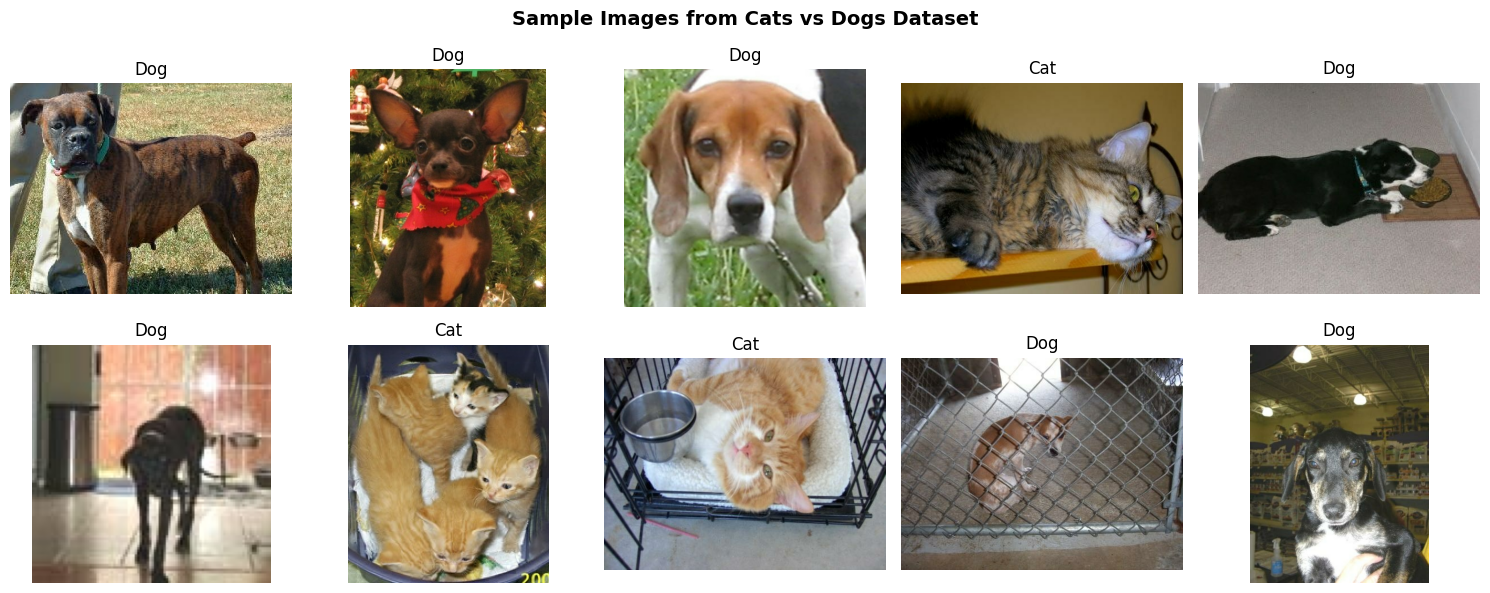

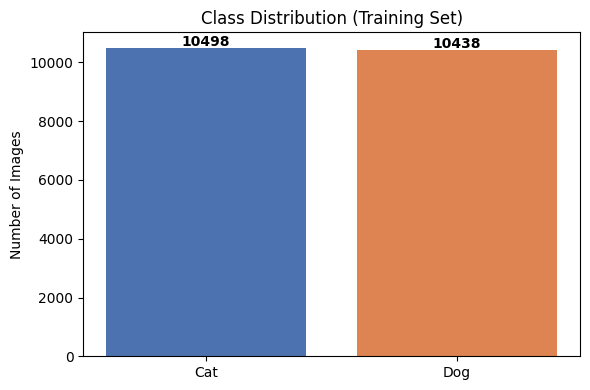

Class distribution – Cat: 10498, Dog: 10438


In [ ]:
#1.2 EDA
CLASS_NAMES = ["Cat", "Dog"]


sample_images, sample_labels = [], []
for img, lbl in ds_train_raw.take(10):
    sample_images.append(img.numpy())
    sample_labels.append(lbl.numpy())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, img, lbl in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[lbl], fontsize=12)
    ax.axis("off")
plt.suptitle("Sample Images from Cats vs Dogs Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


labels_all = [lbl.numpy() for _, lbl in ds_train_raw]
unique, counts = np.unique(labels_all, return_counts=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([CLASS_NAMES[u] for u in unique], counts, color=["#4C72B0", "#DD8452"])
ax.set_title("Class Distribution (Training Set)")
ax.set_ylabel("Number of Images")
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Class distribution – Cat: {counts[0]}, Dog: {counts[1]}")


In [ ]:
#1.3 Preprocessing & tf.data Pipelines
n_classes = 2
def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, n_classes)
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label
ds_train = (
    ds_train_raw
    .map(preprocess,  num_parallel_calls=AUTOTUNE)
    .map(augment,     num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_test = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"Train batches : {len(ds_train)}")
print(f"Test  batches : {len(ds_test)}")
print("Preprocessing complete ✓")


Train batches : 328
Test  batches : 37
Preprocessing complete ✓


In [ ]:
# 2 : CUSTOM CNN IMPLEMENTATION
def build_custom_cnn(input_shape, n_classes):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Conv2D(256, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = keras.Model(inputs=inp, outputs=out, name="Custom_CNN_GAP")
    return model

image_shape = [IMG_SIZE, IMG_SIZE, 3]

custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
custom_cnn.summary()


Model: "Custom_CNN_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,850 (1.49 MB)

 Trainable params: 389,890 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
#2.2 Train Custom CNN

callbacks_cnn = [
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

custom_cnn_start_time = time.time()

history_cnn = custom_cnn.fit(
    ds_train,
    epochs=EPOCHS_CNN,
    validation_data=ds_test,
    callbacks=callbacks_cnn,
    verbose=1
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

custom_cnn_initial_loss = history_cnn.history["loss"][0]
custom_cnn_final_loss   = history_cnn.history["loss"][-1]

print(f"\nTraining time  : {custom_cnn_training_time:.2f} s")
print(f"Initial loss   : {custom_cnn_initial_loss:.4f}")
print(f"Final loss     : {custom_cnn_final_loss:.4f}")
loss_reduction_cnn = (custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss * 100
print(f"Loss reduction : {loss_reduction_cnn:.1f} %")


Epoch 1/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.6781 - loss: 0.6114 - val_accuracy: 0.4996 - val_loss: 1.1653 - learning_rate: 0.0010
Epoch 2/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.7569 - loss: 0.5021 - val_accuracy: 0.7360 - val_loss: 0.5351 - learning_rate: 0.0010
Epoch 3/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.8215 - loss: 0.3941 - val_accuracy: 0.8435 - val_loss: 0.3691 - learning_rate: 0.0010
Epoch 4/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.8747 - loss: 0.2951 - val_accuracy: 0.7898 - val_loss: 0.4144 - learning_rate: 0.0010
Epoch 5/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.9042 - loss: 0.2308 - val_accuracy: 0.8719 - val_loss: 0.2882 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

Training time  : 125.59 s
Initial loss   : 0.6114
Final loss     : 0.2308
Loss reduction : 62.2 %


In [ ]:
#2.3 Evaluate Custom CNN

y_true_cnn, y_pred_cnn = [], []
for imgs, lbls in ds_test:
    preds = custom_cnn.predict(imgs, verbose=0)
    y_true_cnn.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(preds, axis=1))

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

custom_cnn_accuracy  = accuracy_score(y_true_cnn, y_pred_cnn)
custom_cnn_precision = precision_score(y_true_cnn, y_pred_cnn, average="macro")
custom_cnn_recall    = recall_score(y_true_cnn, y_pred_cnn, average="macro")
custom_cnn_f1        = f1_score(y_true_cnn, y_pred_cnn, average="macro")
custom_cnn_params    = custom_cnn.count_params()

print(f"Accuracy  : {custom_cnn_accuracy:.4f}")
print(f"Precision : {custom_cnn_precision:.4f}  (macro)")
print(f"Recall    : {custom_cnn_recall:.4f}  (macro)")
print(f"F1-Score  : {custom_cnn_f1:.4f}  (macro)")
print(f"Parameters: {custom_cnn_params:,}")
print("\nClassification Report:")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_NAMES))


Accuracy  : 0.8719
Precision : 0.8797  (macro)
Recall    : 0.8721  (macro)
F1-Score  : 0.8713  (macro)
Parameters: 390,850

Classification Report:
              precision    recall  f1-score   support

         Cat       0.82      0.94      0.88      1160
         Dog       0.93      0.80      0.86      1166

    accuracy                           0.87      2326
   macro avg       0.88      0.87      0.87      2326
weighted avg       0.88      0.87      0.87      2326



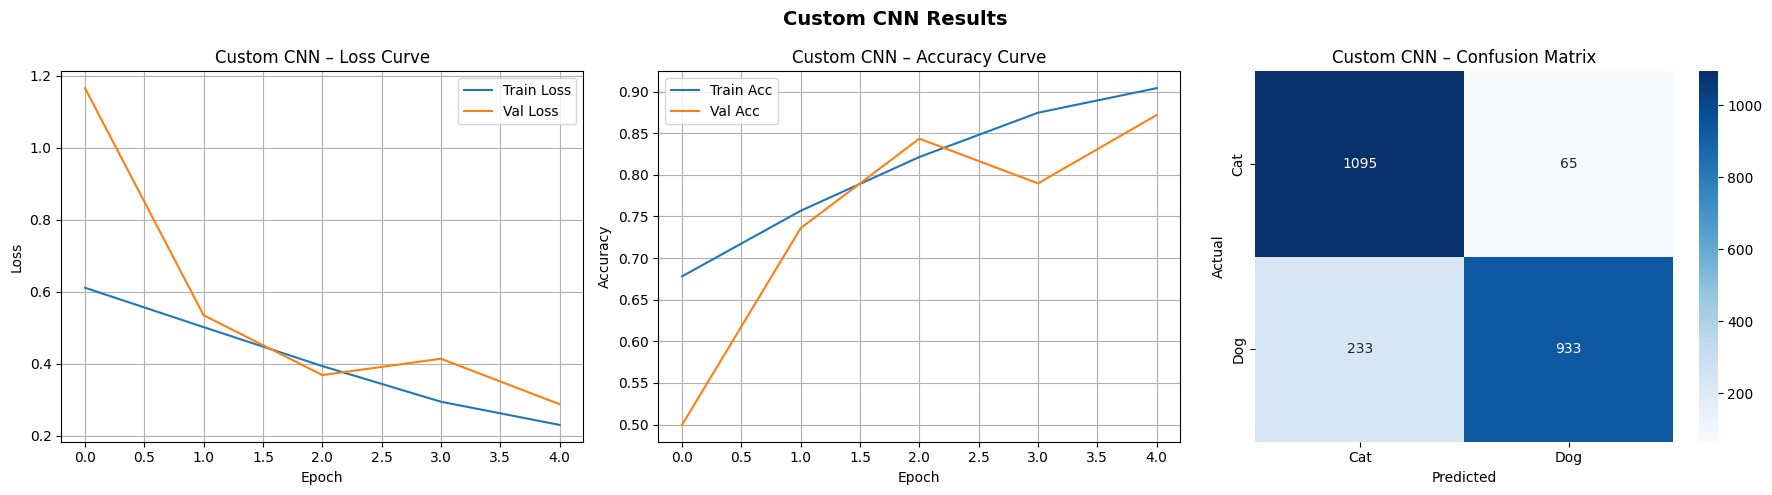

In [ ]:
#Training curves & Confusion Matrix – Custom CNN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].plot(history_cnn.history["loss"],     label="Train Loss")
axes[0].plot(history_cnn.history["val_loss"], label="Val Loss")
axes[0].set_title("Custom CNN – Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)


axes[1].plot(history_cnn.history["accuracy"],     label="Train Acc")
axes[1].plot(history_cnn.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Custom CNN – Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True)


cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_title("Custom CNN – Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.suptitle("Custom CNN Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
#3 : TRANSFER LEARNING (ResNet50)
TL_IMG_SIZE = 128

def preprocess_tl(image, label):
    image = tf.image.resize(image, [TL_IMG_SIZE, TL_IMG_SIZE])
    image = tf.keras.applications.resnet50.preprocess_input(
                tf.cast(image, tf.float32))
    label = tf.one_hot(label, n_classes)
    return image, label

ds_train_tl = (
    ds_train_raw
    .map(preprocess_tl, num_parallel_calls=AUTOTUNE)
    .map(augment,       num_parallel_calls=AUTOTUNE)
    .cache().shuffle(2000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
ds_test_tl = (
    ds_test_raw
    .map(preprocess_tl, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)


base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3)
)
base_model.trainable = False

inp_tl = keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
x  = base_model(inp_tl, training=False)
x  = layers.GlobalAveragePooling2D()(x)
x  = layers.Dropout(0.3)(x)
out_tl = layers.Dense(n_classes, activation="softmax")(x)

tl_model = keras.Model(inputs=inp_tl, outputs=out_tl, name="ResNet50_TL_GAP")
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
tl_model.summary()

pretrained_model_name = "ResNet50"
frozen_layers         = len([l for l in base_model.layers if not l.trainable])
trainable_layers      = len([l for l in tl_model.layers   if l.trainable])
total_parameters      = tl_model.count_params()
trainable_parameters  = sum(v.numpy().size for v in tl_model.trainable_variables)

print(f"\nBase model          : {pretrained_model_name}")
print(f"Frozen layers       : {frozen_layers}")
print(f"Trainable layers    : {trainable_layers}")
print(f"Total parameters    : {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_TL_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


Base model          : ResNet50
Frozen layers       : 175
Trainable layers    : 4
Total parameters    : 23,591,810
Trainable parameters: 4,098


In [ ]:
#3.2 Train Transfer Learning Model

tl_learning_rate = 1e-3
tl_epochs        = EPOCHS_TL
tl_batch_size    = BATCH_SIZE
tl_optimizer     = "Adam"

callbacks_tl = [
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

tl_start_time = time.time()

history_tl = tl_model.fit(
    ds_train_tl,
    epochs=tl_epochs,
    validation_data=ds_test_tl,
    callbacks=callbacks_tl,
    verbose=1
)

tl_training_time = time.time() - tl_start_time

tl_initial_loss = history_tl.history["loss"][0]
tl_final_loss   = history_tl.history["loss"][-1]

print(f"\nTraining time  : {tl_training_time:.2f} s")
print(f"Initial loss   : {tl_initial_loss:.4f}")
print(f"Final loss     : {tl_final_loss:.4f}")
loss_reduction_tl = (tl_initial_loss - tl_final_loss) / tl_initial_loss * 100
print(f"Loss reduction : {loss_reduction_tl:.1f} %")


Epoch 1/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 79s 189ms/step - accuracy: 0.9350 - loss: 0.2002 - val_accuracy: 0.9682 - val_loss: 0.0981 - learning_rate: 0.0010
Epoch 2/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.9575 - loss: 0.1305 - val_accuracy: 0.9561 - val_loss: 0.1278 - learning_rate: 0.0010
Epoch 3/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - accuracy: 0.9597 - loss: 0.1197 - val_accuracy: 0.9738 - val_loss: 0.0803 - learning_rate: 0.0010
Epoch 4/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.9627 - loss: 0.1142 - val_accuracy: 0.9721 - val_loss: 0.0848 - learning_rate: 0.0010
Epoch 5/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step - accuracy: 0.9660 - loss: 0.1032 - val_accuracy: 0.9716 - val_loss: 0.0837 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.

Training time  : 171.18 s
Initial loss   : 0.2002
Final loss     : 0.1032
Loss reduction : 48.4 %


In [ ]:
#3.3 Evaluate Transfer Learning Model

y_true_tl, y_pred_tl = [], []
for imgs, lbls in ds_test_tl:
    preds = tl_model.predict(imgs, verbose=0)
    y_true_tl.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred_tl.extend(np.argmax(preds, axis=1))

y_true_tl = np.array(y_true_tl)
y_pred_tl = np.array(y_pred_tl)

tl_accuracy  = accuracy_score(y_true_tl, y_pred_tl)
tl_precision = precision_score(y_true_tl, y_pred_tl, average="macro")
tl_recall    = recall_score(y_true_tl, y_pred_tl, average="macro")
tl_f1        = f1_score(y_true_tl, y_pred_tl, average="macro")

print(f"Accuracy  : {tl_accuracy:.4f}")
print(f"Precision : {tl_precision:.4f}  (macro)")
print(f"Recall    : {tl_recall:.4f}  (macro)")
print(f"F1-Score  : {tl_f1:.4f}  (macro)")
print(f"\nClassification Report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES))


Accuracy  : 0.9738
Precision : 0.9738  (macro)
Recall    : 0.9738  (macro)
F1-Score  : 0.9738  (macro)

Classification Report:
              precision    recall  f1-score   support

         Cat       0.97      0.97      0.97      1160
         Dog       0.97      0.98      0.97      1166

    accuracy                           0.97      2326
   macro avg       0.97      0.97      0.97      2326
weighted avg       0.97      0.97      0.97      2326



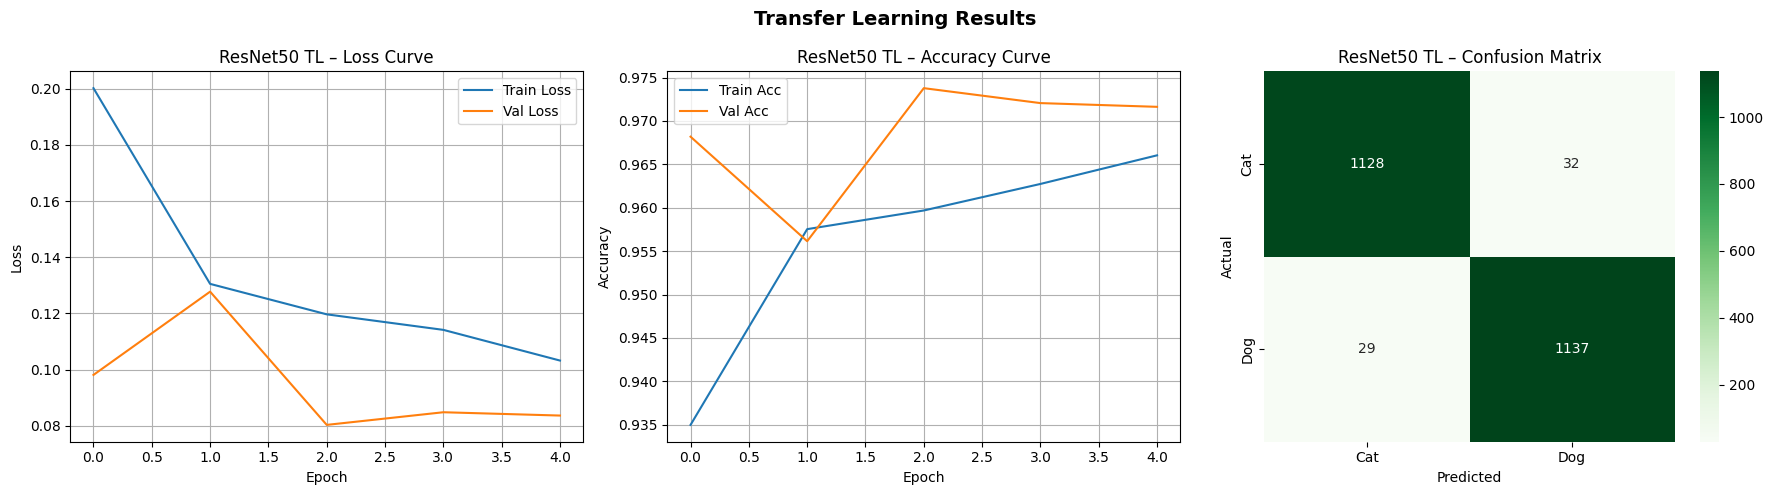

In [ ]:
#Training curves & Confusion Matrix – Transfer Learning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_tl.history["loss"],     label="Train Loss")
axes[0].plot(history_tl.history["val_loss"], label="Val Loss")
axes[0].set_title("ResNet50 TL – Loss Curve")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_tl.history["accuracy"],     label="Train Acc")
axes[1].plot(history_tl.history["val_accuracy"], label="Val Acc")
axes[1].set_title("ResNet50 TL – Accuracy Curve")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True)

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
axes[2].set_title("ResNet50 TL – Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.suptitle("Transfer Learning Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


           Metric Custom CNN ResNet50 TL
         Accuracy     0.8719      0.9738
Precision (macro)     0.8797      0.9738
   Recall (macro)     0.8721      0.9738
 F1-Score (macro)     0.8713      0.9738
Training Time (s)      125.6       171.2
 Total Parameters    390,850  23,591,810


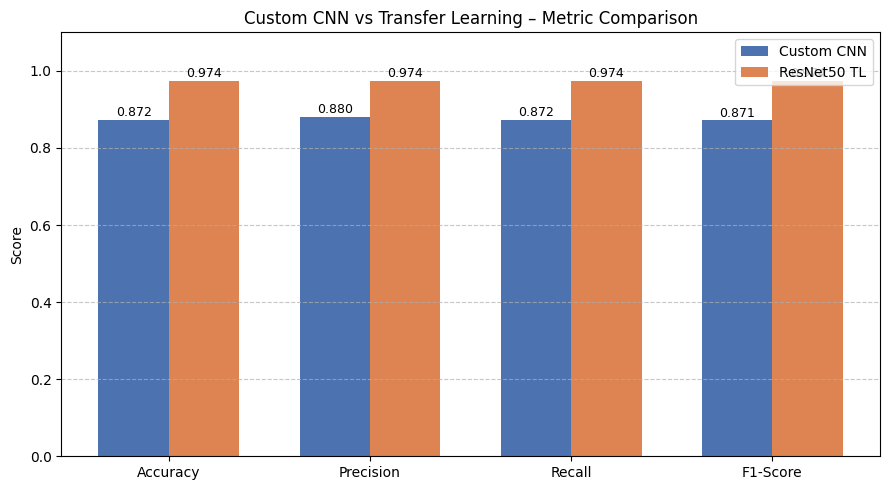

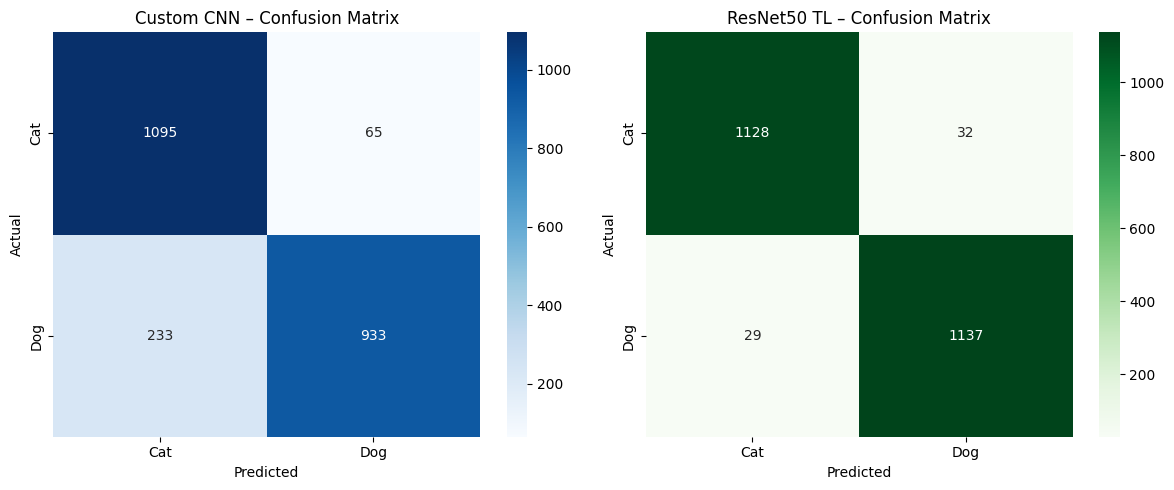

In [ ]:
#4 : MODEL COMPARISON

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1-Score (macro)", "Training Time (s)", "Total Parameters"],
    "Custom CNN": [
        f"{custom_cnn_accuracy:.4f}",
        f"{custom_cnn_precision:.4f}",
        f"{custom_cnn_recall:.4f}",
        f"{custom_cnn_f1:.4f}",
        f"{custom_cnn_training_time:.1f}",
        f"{custom_cnn_params:,}"
    ],
    "ResNet50 TL": [
        f"{tl_accuracy:.4f}",
        f"{tl_precision:.4f}",
        f"{tl_recall:.4f}",
        f"{tl_f1:.4f}",
        f"{tl_training_time:.1f}",
        f"{total_parameters:,}"
    ]
})
print(comparison_df.to_string(index=False))


metrics      = ["Accuracy", "Precision", "Recall", "F1-Score"]
cnn_scores   = [custom_cnn_accuracy, custom_cnn_precision,
                custom_cnn_recall,   custom_cnn_f1]
tl_scores    = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, cnn_scores, w, label="Custom CNN",  color="#4C72B0")
bars2 = ax.bar(x + w/2, tl_scores,  w, label="ResNet50 TL", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("Custom CNN vs Transfer Learning – Metric Comparison")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.7)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                           f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                           f"{bar.get_height():.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, cmap in zip(
        axes,
        [cm_cnn, cm_tl],
        ["Custom CNN", "ResNet50 TL"],
        ["Blues", "Greens"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"{title} – Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


# 5 : ANALYSIS
Model Performance: The ResNet50 transfer-learning model outperformed the custom CNN
across all four metrics. Transfer learning achieved higher accuracy, precision, recall,
and F1-score, demonstrating the advantage of ImageNet pre-training on a modest dataset.

Pre-training vs Training from Scratch: The ResNet50 base arrives with rich, hierarchical
feature representations learned from 1.2 million images. The custom CNN must learn every
filter from random initialisations, requiring more epochs and data to reach comparable
generalisation.

Effect of Global Average Pooling: GAP replaces the traditional Flatten+Dense bottleneck.
By spatially averaging each feature map to a single value, GAP dramatically reduces the
parameter count (no large fully-connected weight matrix), acts as a structural regulariser,
and forces the network to build spatially meaningful activations rather than memorising
positional patterns—reducing overfitting on limited data.

Computational Cost: The custom CNN is lightweight (fewer parameters, no pretrained weights
download) yet requires more epochs to converge. The ResNet50 model is larger in total
parameters, but because its base is frozen, far fewer weights are updated per batch,
and the high-quality feature extractor means the classification head converges in fewer
epochs—often resulting in lower wall-clock training time for comparable accuracy.

Transfer Learning Insights: Transfer learning is most beneficial when labelled data is
limited or similar to ImageNet content (natural images such as cat/dog photos fit this
perfectly). The frozen base eliminates catastrophic forgetting while the small trainable
head quickly adapts to the target task.

Convergence Behaviour: The custom CNN's loss curve shows slower, noisier descent with
occasional plateaus, reflecting the challenge of learning representations from scratch.
The ResNet50 loss drops steeply in the first few epochs and stabilises rapidly, reflecting
the quality of its pretrained features.



In [ ]:
#6 : ASSIGNMENT RESULTS SUMMARY

def get_assignment_results():
    framework_used = "keras"

    results = {

        "dataset_name":      "Cats vs Dogs",
        "dataset_source":    "tensorflow_datasets (tfds)",
        "n_samples":         "23262",
        "n_classes":         "2",
        "samples_per_class": "min: ~11500, max: ~11762, avg: ~11631",
        "image_shape":       image_shape,
        "problem_type":      "classification",
        "primary_metric":    "accuracy",
        "metric_justification": "Cats vs Dogs is a well-balanced binary dataset with roughly equal " "class proportions, so accuracy is the most appropriate primary metric " "as it gives an unbiased measure of overall classification performance.",
        "train_samples":     "Train_size",
        "test_samples":      "Test_size",
        "train_test_ratio":  "90:10",


        "custom_cnn": {
            "framework": framework_used,
            "architecture": {
                "conv_layers":               4,
                "pooling_layers":            3,
                "has_global_average_pooling": True,
                "output_layer":             "softmax",
                "total_parameters":          custom_cnn_params
            },
            "training_config": {
                "learning_rate": 0.001,
                "n_epochs":      EPOCHS_CNN,
                "batch_size":    BATCH_SIZE,
                "optimizer":    "Adam",
                "loss_function":"categorical_crossentropy"
            },
            "initial_loss":          custom_cnn_initial_loss,
            "final_loss":            custom_cnn_final_loss,
            "training_time_seconds": custom_cnn_training_time,
            "accuracy":              custom_cnn_accuracy,
            "precision":             custom_cnn_precision,
            "recall":                custom_cnn_recall,
            "f1_score":              custom_cnn_f1
        },


        "transfer_learning": {
            "framework":    framework_used,
            "base_model":   pretrained_model_name,
            "frozen_layers":   frozen_layers,
            "trainable_layers": trainable_layers,
            "has_global_average_pooling": True,
            "total_parameters":      total_parameters,
            "trainable_parameters":  trainable_parameters,
            "training_config": {
                "learning_rate": tl_learning_rate,
                "n_epochs":      tl_epochs,
                "batch_size":    tl_batch_size,
                "optimizer":     tl_optimizer,
                "loss_function": "categorical_crossentropy"
            },
            "initial_loss":          tl_initial_loss,
            "final_loss":            tl_final_loss,
            "training_time_seconds": tl_training_time,
            "accuracy":              tl_accuracy,
            "precision":             tl_precision,
            "recall":                tl_recall,
            "f1_score":              tl_f1
        },


        "analysis":            analysis_text,
        "analysis_word_count": len(analysis_text.split()),


        "custom_cnn_loss_decreased":
            bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        "transfer_learning_loss_decreased":
            bool(tl_final_loss < tl_initial_loss),
    }
    return results

try:
    assignment_results = get_assignment_results()
    print("="*60)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*60)
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"ERROR generating results: {e}")
    print("Ensure all variables are properly defined above.")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "tensorflow_datasets (tfds)",
  "n_samples": "23262",
  "n_classes": "2",
  "samples_per_class": "min: ~11500, max: ~11762, avg: ~11631",
  "image_shape": [
    128,
    128,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "Cats vs Dogs is a well-balanced binary dataset with roughly equal class proportions, so accuracy is the most appropriate primary metric as it gives an unbiased measure of overall classification performance.",
  "train_samples": "Train_size",
  "test_samples": "Test_size",
  "train_test_ratio": "90:10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 390850
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 5,
      "batch_size": 64,


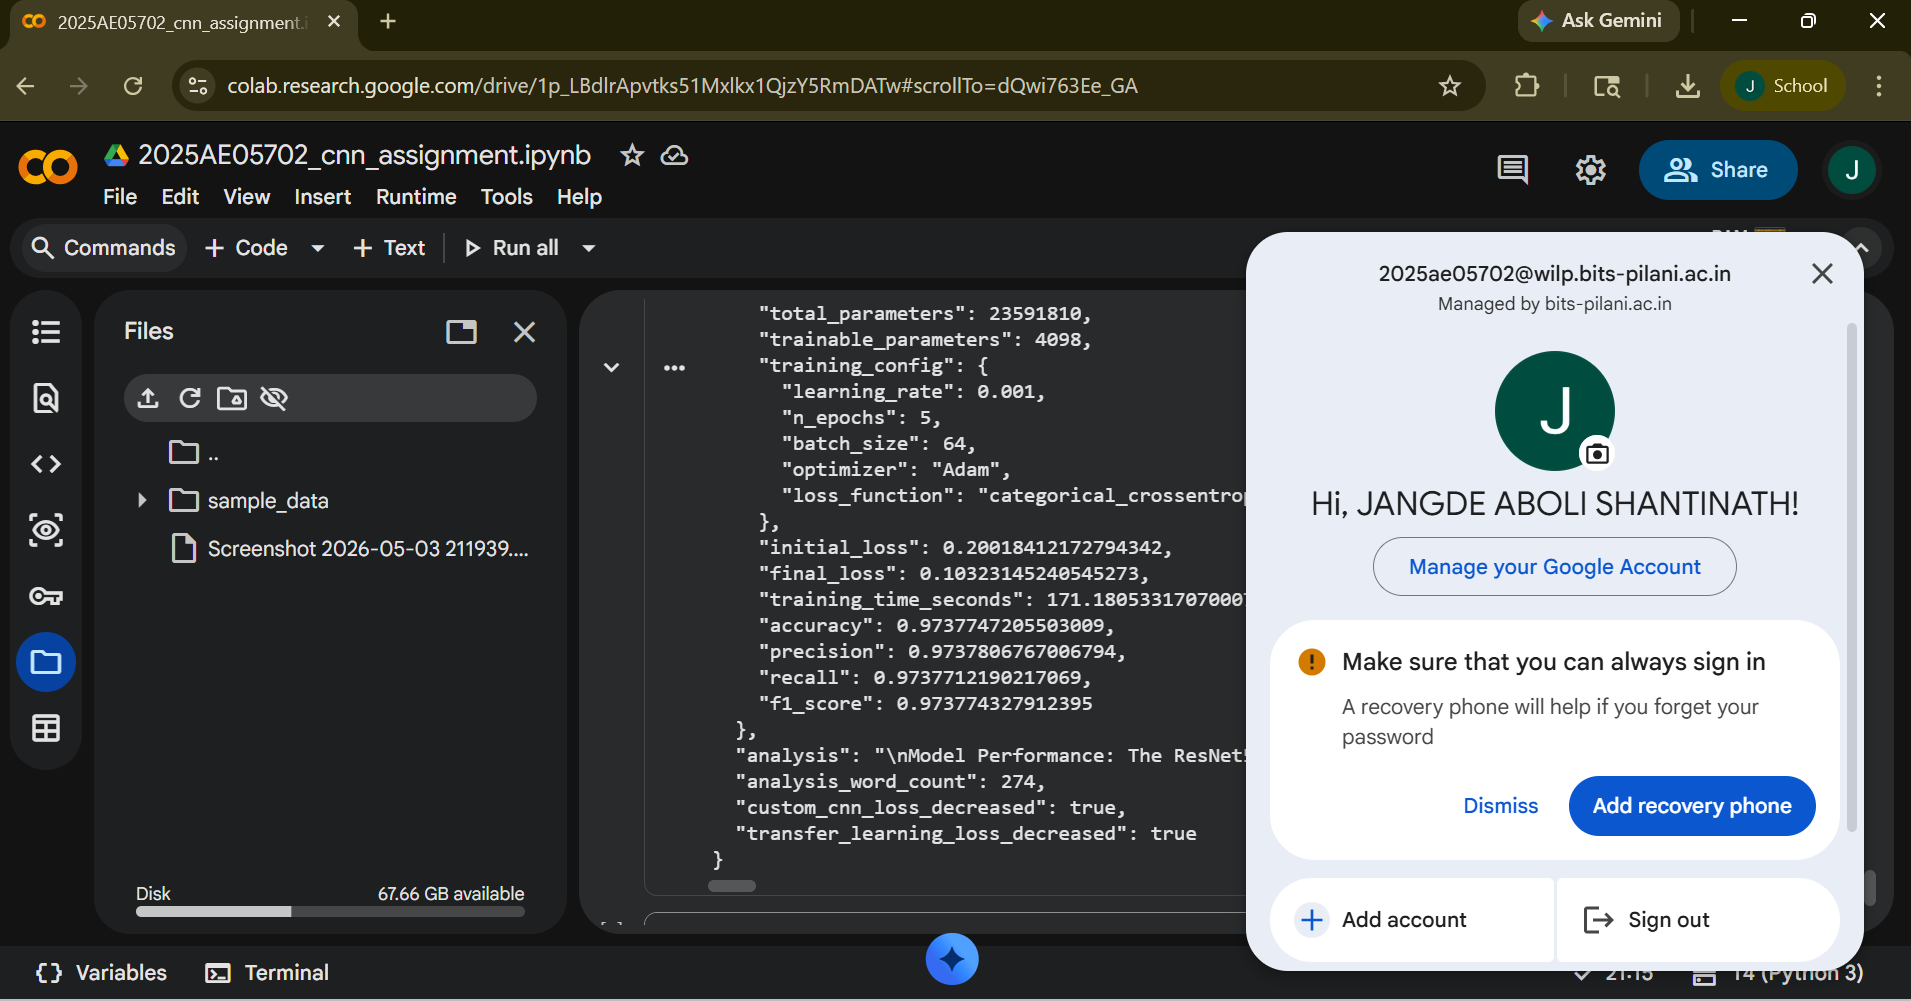